# Ring AllReduce Per-Chunk Timeline Visualization

Visualizes the pipeline behavior of **Ring AllReduce** using real per-chunk timing data.

Features:
- Parses **all 4 rank files** (r-0 through r-3) for each config
- Shows Rank 0's send timeline (POST_TO_DR / DR_TO_TX / TX_TO_DONE) per channel, each chunk on its own line
- **TX_TO_DONE bar is split** at the receiver's `ABS_RX_DONE` (pre-aligned by the gauge to sender's func_start frame)
- Supports multiple message sizes and configs (0x0, 0x7, 0x7-LL, etc.)
- `[ALIGN]` and `[ANCHOR]` fields are parsed for diagnostics only (no manual alignment needed)


In [5]:
import re
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Shared parsing primitives (test-case split, header/INFO fields, per-chunk metric findall).
sys.path.insert(0, os.path.abspath('..'))   # profiler_timeline_visualization/ (holds common/)
from common import parsing as P
from common.parsing import pick as _pick, STAT   # _pick/STAT kept as local names (used below)

# Raw .out files live with the per-mask model notebooks (one folder per NCCL_TESTS_SPLIT_MASK);
# figures are written next to this notebook.
DATA_DIRS = {                                        # inputs (.out), per mask
    '0x0': '../../../p5en-allreduce-0x0-notebook',
    '0x7': '../../../p5en-allreduce-0x7-notebook',
}
OUT_DIR = '.'                                        # outputs (.png), this notebook's folder


def parse_ring_file_v2(filepath):
    """Parse a single rank's output file (new format with clock offsets, ABS_TX, recv sections).
    May contain multiple test cases (message sizes). Returns a list of per-message dicts.

    Generic parts (test-case split, message header, INFO fields, nchunks, T total, section
    split, per-chunk metric findall) come from common.parsing; the ring-specific section
    assembly (clock/anchor/align, send/recv/rail/ctrl) stays here."""
    with open(filepath, 'r') as f:
        content = f.read()

    msg_cases = []
    for tc in P.split_test_cases(content):
        msg_label, msg_bytes = P.parse_msg_header(tc)
        if msg_label is None:
            continue

        # 1) Clock offsets (ring-specific diagnostic block)
        clock_offsets = {}
        clock_block = re.search(r'==== BEGIN clock_pingpong_offsets ====(.*?)====\s*END clock_pingpong_offsets\s*====', tc, re.DOTALL)
        if clock_block:
            for line in clock_block.group(1).strip().split('\n'):
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                parts = line.split()
                if len(parts) >= 3:
                    clock_offsets[parts[1]] = int(parts[2])

        # 2) Rank -> hostname
        rank_host_match = re.search(r'\[Rank (\d+) @ ([^\]]+)\]', tc)
        rank_id = int(rank_host_match.group(1)) if rank_host_match else None
        hostname = rank_host_match.group(2) if rank_host_match else None

        # 3) INFO line + nthreads + buffsize (generic)
        _f = P.parse_info_fields(tc)
        nranks, nchannels, protocol = _f['nranks'], _f['nchannels'], _f['protocol']
        nthreads, buffsize = _f['nthreads'], _f['buffsize']

        # 4) ANCHOR (diagnostic only)
        anchor_match = re.search(r'\[ANCHOR\][^:]*:\s*(\d+)', tc)
        anchor_ns = int(anchor_match.group(1)) if anchor_match else None

        # 4b) [ALIGN] fields (diagnostic)
        align_on = bool(re.search(r'\[ALIGN\] cross_rank_recv_alignment=on', tc))
        align_offsets = {}
        align_line_match = re.search(r'\[ALIGN\] clock_offsets_ns \(rank order\): (.+)', tc)
        if align_line_match:
            for rm in re.findall(r'r(\d+)=(-?\d+)', align_line_match.group(1)):
                align_offsets[int(rm[0])] = int(rm[1])

        # 5) nchunks per channel + T total (generic)
        nchunks_per_channel = P.parse_nchunks(tc)
        t_total = P.parse_t_total(tc)

        # 6) Send sections
        sends = []
        for peer, channel, section in P.split_sections(tc, r'-- --- send to peer (\d+) in channel (\d+) ---'):
            post_gap_matches = P.findall_metric(section, r'\[POST_GAP\] chunk (\d+) post gap from chunk 0:\s*(.+?) ms')
            post_to_dr_matches = P.findall_metric(section, r'\[POST_TO_DR\] chunk (\d+) posted .+? data ready:\s*(.+?) ms')
            post_to_recvdone_matches = P.findall_metric(section, r'\[POST_TO_RECVDONE\] chunk (\d+) posted .+? recv done\s*:\s*(.+?) ms')
            recvdone_to_dr_matches = P.findall_metric(section, r'\[RECVDONE_TO_DR\] chunk (\d+) recv done .+? data ready\s*:\s*(.+?) ms')
            dr_to_tx_matches = P.findall_metric(section, r'\[DR_TO_TX\] chunk (\d+) data ready .+? transmitted:\s*(.+?) ms')
            tx_to_done_matches = P.findall_metric(section, r'\[TX_TO_DONE\] chunk (\d+) transmitted .+? done:\s*(.+?) ms')
            abs_tx_matches = P.findall_metric(section, r'\[ABS_TX\] chunk (\d+) transmitted @ func_start \+\s*(.+?) ms')
            abs_tx_done_matches = P.findall_metric(section, r'\[ABS_TX_DONE\] chunk (\d+) send done @ func_start \+\s*(.+?) ms')

            post_to_recvdone_map = dict(post_to_recvdone_matches)
            recvdone_to_dr_map = dict(recvdone_to_dr_matches)
            chunks = []
            for j in range(len(post_gap_matches)):
                chunk_id = post_gap_matches[j][0]
                post_gap = post_gap_matches[j][1]
                post_to_dr = post_to_dr_matches[j][1] if j < len(post_to_dr_matches) else 0
                dr_to_tx = dr_to_tx_matches[j][1] if j < len(dr_to_tx_matches) else 0
                tx_to_done = tx_to_done_matches[j][1] if j < len(tx_to_done_matches) else 0
                abs_tx = abs_tx_matches[j][1] if j < len(abs_tx_matches) else None
                abs_tx_done = abs_tx_done_matches[j][1] if j < len(abs_tx_done_matches) else None
                chunks.append({
                    'chunk_id': chunk_id, 'post_gap': post_gap, 'post_to_dr': post_to_dr, 'dr_to_tx': dr_to_tx, 'tx_to_done': tx_to_done,
                    'post_to_recvdone': post_to_recvdone_map.get(chunk_id), 'recvdone_to_dr': recvdone_to_dr_map.get(chunk_id),
                    'total': post_to_dr + dr_to_tx + tx_to_done,
                    'abs_tx': abs_tx, 'abs_tx_done': abs_tx_done,
                })
            sends.append({'peer': peer, 'channel': channel, 'chunks': chunks})

        # 7) Recv sections
        recvs = []
        for peer, channel, section in P.split_sections(tc, r'-- --- recv from peer (\d+) in channel (\d+) ---'):
            r0_matches = P.findall_metric(section, r'\[R0\] chunk (\d+) Irecv post gap from chunk 0:\s*(.+?) ms')
            rw_matches = P.findall_metric(section, r'\[R_wait\] chunk (\d+) Irecv posted .+? done:\s*(.+?) ms')
            abs_rx_post_matches = P.findall_metric(section, r'\[ABS_RX_POST\] chunk (\d+) Irecv posted @ func_start \+\s*(.+?) ms')
            abs_rx_done_matches = P.findall_metric(section, r'\[ABS_RX_DONE\] chunk (\d+) Irecv done\s+@ func_start \+\s*(.+?) ms')
            abs_rx_post_map = dict(abs_rx_post_matches)
            abs_rx_done_map = dict(abs_rx_done_matches)
            chunks = []
            for j in range(len(r0_matches)):
                chunk_id = r0_matches[j][0]
                r0 = r0_matches[j][1]
                r_wait = rw_matches[j][1] if j < len(rw_matches) else 0
                chunks.append({
                    'chunk_id': chunk_id, 'r0': r0, 'r_wait': r_wait,
                    'abs_rx_post': abs_rx_post_map.get(chunk_id), 'abs_rx_done': abs_rx_done_map.get(chunk_id),
                })
            recvs.append({'peer': peer, 'channel': channel, 'chunks': chunks})

        # 8) Per-rail timing sections
        rails = []
        for channel, peer, section in P.split_sections(tc, r'-- --- plugin per-rail timing: channel (\d+) peer (\d+) ---'):
            rail_data = []
            starts = re.findall(r'\[RAIL_START\] channel \d+ peer \d+ chunk (\d+) rail (\d+) start @ func_start \+\s*(.+?) ms', section)
            ends = re.findall(r'\[RAIL_END\]\s+channel \d+ peer \d+ chunk (\d+) rail (\d+) end\s+@ func_start \+\s*(.+?) ms', section)
            for (chunk_id, rail_id, start_ms) in starts:
                rail_data.append({'chunk_id': int(chunk_id), 'rail': int(rail_id), 'start_ms': _pick(start_ms), 'end_ms': None})
            for (chunk_id, rail_id, end_ms) in ends:
                for rd in rail_data:
                    if rd['chunk_id'] == int(chunk_id) and rd['rail'] == int(rail_id) and rd['end_ms'] is None:
                        rd['end_ms'] = _pick(end_ms)
                        break
            rails.append({'channel': channel, 'peer': peer, 'chunks': rail_data})

        # 9) CTRL_ARRIVAL
        ctrl_arrivals = {}
        for m in re.finditer(r'\[CTRL_ARRIVAL\] channel (\d+) peer (\d+) chunk (\d+) ctrl seen @ func_start \+\s*(.+?) ms', tc):
            ctrl_arrivals[(int(m.group(1)), int(m.group(2)), int(m.group(3)))] = _pick(m.group(4))

        msg_cases.append({
            'msg_label': msg_label, 'msg_bytes': msg_bytes,
            'nranks': nranks, 'nchannels': nchannels,
            'nchunks_per_channel': nchunks_per_channel,
            't_total': t_total, 'protocol': protocol,
            'nthreads': nthreads, 'buffsize': buffsize,
            'rank_id': rank_id, 'hostname': hostname,
            'anchor_ns': anchor_ns, 'clock_offsets': clock_offsets,
            'align_on': align_on, 'align_offsets': align_offsets,
            'sends': sends, 'recvs': recvs, 'rails': rails,
            'ctrl_arrivals': ctrl_arrivals,
        })

    msg_cases.sort(key=lambda m: m['msg_bytes'])
    return msg_cases


def load_all_ranks(cfg_name, file_paths):
    """Load all rank files for a config, organize by (msg_bytes, protocol).
    Returns list of per-test-case dicts with per_rank data.
    Handles files with multiple protocols (e.g. Simple, LL, LL128) for the same msg size."""
    # Parse each rank file
    all_ranks_raw = {}  # rank_id -> [msg_cases]
    for path in file_paths:
        if not os.path.exists(path):
            continue
        cases = parse_ring_file_v2(path)
        if cases:
            rank_id = cases[0]['rank_id']
            all_ranks_raw[rank_id] = cases

    if not all_ranks_raw:
        return []

    # Group by (msg_bytes, protocol) across ranks using rank 0 as reference
    ref_rank = min(all_ranks_raw.keys())
    result = []
    for mi, ref_case in enumerate(all_ranks_raw[ref_rank]):
        msg_bytes = ref_case['msg_bytes']
        protocol = ref_case['protocol']
        nchannels = ref_case['nchannels']
        nthreads = ref_case.get('nthreads')
        buffsize = ref_case.get('buffsize')
        entry = {
            'msg_label': ref_case['msg_label'],
            'msg_bytes': msg_bytes,
            'nranks': ref_case['nranks'],
            'nchannels': ref_case['nchannels'],
            'nchunks_per_channel': ref_case['nchunks_per_channel'],
            't_total': ref_case['t_total'],
            'protocol': protocol,
            'nthreads': nthreads,
            'buffsize': buffsize,
            'per_rank': {},
        }
        for rank_id, cases in all_ranks_raw.items():
            # Match by index (same ordering guaranteed since same experiment)
            if mi < len(cases) and cases[mi]['msg_bytes'] == msg_bytes and cases[mi]['protocol'] == protocol and cases[mi]['nchannels'] == nchannels and cases[mi].get('nthreads') == nthreads and cases[mi].get('buffsize') == buffsize:
                c = cases[mi]
                entry['per_rank'][rank_id] = {
                    'anchor_ns': c['anchor_ns'],
                    'hostname': c['hostname'],
                    'clock_offsets': c['clock_offsets'],
                    'align_on': c.get('align_on', False),
                    'align_offsets': c.get('align_offsets', {}),
                    'sends': c['sends'],
                    'recvs': c['recvs'],
                    'rails': c.get('rails', []),
                    'ctrl_arrivals': c.get('ctrl_arrivals', {}),
                    'protocol': c['protocol'],
                }
        result.append(entry)
    return result


# Load configs — 0x7 and 0x0 files (both contain Simple, LL, LL128 protocols)
configs = {}
for suffix, ddir in DATA_DIRS.items():
    paths = [os.path.join(ddir, f'nccl_allreduce_ring_inter_r-{r}-{suffix}.out') for r in range(4)]
    paths = [p for p in paths if os.path.exists(p)]   # keep whatever rank files exist (r1-r3 optional)
    if paths and os.path.exists(os.path.join(ddir, f'nccl_allreduce_ring_inter_r-0-{suffix}.out')):
        configs[suffix] = paths

ring_data = {}
for cfg, paths in configs.items():
    ring_data[cfg] = load_all_ranks(cfg, paths)

print(f"Loaded configs (new format with multi-rank), using STAT='{STAT}' per chunk:")
for cfg, cases in ring_data.items():
    print(f"\n  {cfg}: {len(cases)} message sizes")
    for info in cases:
        ranks_loaded = sorted(info['per_rank'].keys())
        print(f"    msg={info['msg_label']}, nranks={info['nranks']}, nch={info['nchannels']}, "
              f"nthreads={info.get('nthreads')}, buffsize={info.get('buffsize')}, protocol={info['protocol']}, ranks_loaded={ranks_loaded}, nchunks/ch={info['nchunks_per_channel']}")
        # Print anchor/offset diagnostics for rank 0
        r0 = info['per_rank'].get(0)
        if r0:
            align_str = "ON (gauge pre-aligned ABS_RX_DONE)" if r0.get('align_on') else "OFF"
            print(f"      align={align_str}")
            print(f"      rank0 anchor={r0['anchor_ns']}, host={r0['hostname']}")
            print(f"      clock_offsets (hostname): {r0['clock_offsets']}")
            if r0.get('align_offsets'):
                print(f"      align_offsets (rank): {r0['align_offsets']}")


Loaded configs (new format with multi-rank), using STAT='med' per chunk:

  0x0: 34 message sizes
    msg=64MB, nranks=32, nch=8, nthreads=512, buffsize=16KB, protocol=LL, ranks_loaded=[0], nchunks/ch=15872
      align=OFF
      rank0 anchor=None, host=p5en-odcr-queue-dy-p5en48xlarge-25
      clock_offsets (hostname): {}
    msg=64MB, nranks=32, nch=8, nthreads=512, buffsize=32KB, protocol=LL, ranks_loaded=[0], nchunks/ch=7936
      align=OFF
      rank0 anchor=None, host=p5en-odcr-queue-dy-p5en48xlarge-25
      clock_offsets (hostname): {}
    msg=64MB, nranks=32, nch=8, nthreads=512, buffsize=64KB, protocol=LL, ranks_loaded=[0], nchunks/ch=3968
      align=OFF
      rank0 anchor=None, host=p5en-odcr-queue-dy-p5en48xlarge-25
      clock_offsets (hostname): {}
    msg=64MB, nranks=32, nch=8, nthreads=512, buffsize=128KB, protocol=LL, ranks_loaded=[0], nchunks/ch=1984
      align=OFF
      rank0 anchor=None, host=p5en-odcr-queue-dy-p5en48xlarge-25
      clock_offsets (hostname): {}
    

In [6]:
from common import plotting as PL
def compute_rx_done_in_rank0(info, sender_rank=0):
    """For each chunk sent by sender_rank, get the receiver's ABS_RX_DONE.
    The gauge already outputs ABS_RX_DONE relative to the SENDER's func_start
    (alignment done internally by the gauge), so we just read the value directly.
    Returns: dict[(channel, chunk_id)] -> rx_done_ms (in sender's func_start frame)"""
    nranks = info['nranks']
    recv_rank = (sender_rank + 1) % nranks

    rx_data = info['per_rank'].get(recv_rank)
    if not rx_data:
        return {}

    rx_done_map = {}
    for recv_sec in rx_data['recvs']:
        if recv_sec['peer'] != sender_rank:
            continue
        ch = recv_sec['channel']
        for c in recv_sec['chunks']:
            if c['abs_rx_done'] is not None:
                rx_done_map[(ch, c['chunk_id'])] = c['abs_rx_done']
    return rx_done_map


def plot_ring_chunk_range(cfg, info, chunk_start, chunk_end, title_suffix, save_name):
    """Plot Rank-0 ring send timeline — all T segments on one row per chunk."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    FS = 13   # one uniform font size for everything in this figure

    C_BG = 'white'
    C_POST_TO_RECVDONE = '#E74C3C'
    C_RECVDONE_TO_DR = '#3498DB'
    C_POST_TO_DR = '#D94F4F'
    C_DR_TO_TX = '#F5A623'
    C_TX_TO_DONE = '#8E44AD'
    C_RAIL0 = '#2980B9'
    C_RAIL1 = '#E67E22'
    C_WIRE  = '#16A085'   # theoretical wire time = chunk/BW + 2L
    C_TEXT = '#2C3E50'
    C_RING = '#3B7DD8'

    n_chunks = chunk_end - chunk_start
    box_height = 0.55
    chunk_row_gap = 0.78  # compact: row only slightly taller than the label text
    group_gap = 1.2
    lane_h = 0.30          # height of each lane's bar
    bar_h  = lane_h * 0.45  # thin bar height (same for upper-lane boxes AND rails)
    lane_off = 0.16        # vertical offset of upper/lower lane from chunk center

    # Get rank 0 sends
    r0_data = info['per_rank'][0]
    sends_sorted = sorted(r0_data['sends'], key=lambda s: s['channel'])
    groups = []
    for s in sends_sorted:
        if s['channel'] != 0:          # only show channel 0
            continue
        sliced = [c for c in s['chunks'] if chunk_start <= c['chunk_id'] < chunk_end]
        if sliced:
            label = f"Rank 0 → Rank {s['peer']} (channel {s['channel']})"
            groups.append((label, s['channel'], sliced))

    if not groups:
        print(f"No data for cfg={cfg}, chunks {chunk_start}-{chunk_end-1}")
        return

    # Build per-chunk rail timing lookup
    rail_map = {}
    post0_gap = None
    for _, ch, chunks in groups:
        for c in chunks:
            if c.get('abs_tx') is not None:
                post0_gap = c['abs_tx'] - (c['post_gap'] + c['post_to_dr'] + c['dr_to_tx'])
                break
        if post0_gap is not None:
            break
    if post0_gap is not None:
        for rail_sec in r0_data.get('rails', []):
            for rd in rail_sec['chunks']:
                if rd['start_ms'] is not None and rd['end_ms'] is not None:
                    key = (rail_sec['channel'], rd['chunk_id'], rd['rail'])
                    rail_map[key] = (rd['start_ms'] - post0_gap, rd['end_ms'] - post0_gap)

    # Y layout: one row per chunk per group
    n_groups = len(groups)
    y_map = []  # y_map[g_idx][ci] = y position
    current_y = 0
    for g in range(n_groups):
        group_y = []
        for ci in range(n_chunks):
            group_y.append(current_y)
            current_y -= chunk_row_gap
        y_map.append(group_y)
        current_y -= group_gap

    y_top = y_map[0][0] + 1.2
    y_bottom = y_map[-1][-1] - 0.7

    min_time = float('inf')
    max_time = 0
    for label, ch, chunks in groups:
        for c in chunks:
            min_time = min(min_time, c['post_gap'])
            max_time = max(max_time, c['post_gap'] + c['total'])

    # Chunk size
    msg_bytes = info['msg_bytes']
    nchannels = info['nchannels']
    nchunks_per_ch = info['nchunks_per_channel']
    nranks = info['nranks']
    chunk_size_bytes = msg_bytes * 2 * (nranks - 1) / (nranks * nchannels * nchunks_per_ch) if nchunks_per_ch else 0
    chunk_size_str = PL.fmt_bytes(chunk_size_bytes)

    # Averages
    group_avgs = []
    for label, ch, chunks in groups:
        avg_post_to_dr = np.mean([c['post_to_dr'] for c in chunks])
        avg_dr_to_tx = np.mean([c['dr_to_tx'] for c in chunks])
        avg_recvdone_to_dr = np.mean([c['recvdone_to_dr'] for c in chunks if c.get('recvdone_to_dr') is not None]) if any(c.get('recvdone_to_dr') is not None for c in chunks) else 0
        avg_tx_to_done = np.mean([c['tx_to_done'] for c in chunks])
        group_avgs.append((avg_post_to_dr, avg_dr_to_tx, avg_recvdone_to_dr, avg_tx_to_done))

    fig_height = max(5, abs(y_top - y_bottom) * 0.42 + 1.4)
    fig, ax = plt.subplots(1, 1, figsize=(18, fig_height), facecolor=C_BG)
    ax.set_facecolor(C_BG)

    time_span = max_time - min_time if max_time > min_time else 1.0
    chunk_id_x = min_time - time_span * 0.025

    for g_idx, (label, ch, chunks) in enumerate(groups):
        g_y_top = y_map[g_idx][0]
        g_y_bottom = y_map[g_idx][-1]

        # Group background
        bg_color = 'white'
        rect = mpatches.FancyBboxPatch(
            (chunk_id_x - time_span * 0.04, g_y_bottom - box_height/2 - 0.3),
            (max_time - chunk_id_x) + time_span * 0.08,
            (g_y_top - g_y_bottom) + box_height + 0.6,
            boxstyle="round,pad=0.06", facecolor=bg_color,
            edgecolor='#E2E8F0', linewidth=0.5, zorder=0)
        ax.add_patch(rect)

        # Group header
        avg_post_to_dr, avg_dr_to_tx, avg_recvdone_to_dr, avg_tx_to_done = group_avgs[g_idx]
        header_y = g_y_top + box_height/2 + 0.6
        header = (f"{label},  avg T_wait+T_mem={avg_post_to_dr:.3f},  T_mem={avg_recvdone_to_dr:.3f},  T_launch={avg_dr_to_tx:.4f},  T_send={avg_tx_to_done:.3f} ms")
        ax.text(chunk_id_x - time_span * 0.03, header_y, header,
                ha='left', va='center', fontsize=FS, fontweight='bold', color=C_RING)

        for ci, c in enumerate(chunks):
            y = y_map[g_idx][ci]

            # two lanes per chunk:
            #   upper = measured POST_TO_RECVDONE / DR_TO_TX / TX_TO_DONE
            #   lower = actual rail0 / rail1 transmission windows (aligned under TX_TO_DONE)
            y_up = y + lane_off
            y_dn = y - lane_off * 0.2

            # dashed separator between chunks (below this chunk)
            sep_y = y - chunk_row_gap / 2
            ax.plot([chunk_id_x - time_span * 0.04, max_time],
                    [sep_y, sep_y], ls='--', color='#B0B8C0', lw=0.7, alpha=0.6, zorder=1)

            # Chunk ID label (larger font, at chunk center)
            ax.text(chunk_id_x, y, f"c{c['chunk_id']}", ha='right', va='center',
                    fontsize=FS, color=C_TEXT, fontweight='bold', zorder=6)

            post_to_recvdone = c.get('post_to_recvdone')
            recvdone_to_dr = c.get('recvdone_to_dr')

            # ===== UPPER LANE: POST_TO_RECVDONE -> RECVDONE_TO_DR (or POST_TO_DR), DR_TO_TX, TX_TO_DONE (+rails) =====
            x_start = c['post_gap']
            if post_to_recvdone is not None and recvdone_to_dr is not None:
                if post_to_recvdone > 0.001:
                    ax.add_patch(FancyBboxPatch((x_start, y_up - bar_h/2), post_to_recvdone, bar_h,
                        boxstyle="square,pad=0", facecolor=C_POST_TO_RECVDONE, edgecolor='#C0392B',
                        linewidth=0.5, alpha=0.85, zorder=5))
                if recvdone_to_dr > 0.001:
                    ax.add_patch(FancyBboxPatch((x_start + post_to_recvdone, y_up - bar_h/2), recvdone_to_dr, bar_h,
                        boxstyle="square,pad=0", facecolor=C_RECVDONE_TO_DR, edgecolor='#2471A3',
                        linewidth=0.5, alpha=0.85, zorder=5))
            else:
                w = c['post_to_dr']
                if w > 0.001:
                    ax.add_patch(FancyBboxPatch((x_start, y_up - bar_h/2), w, bar_h,
                        boxstyle="square,pad=0", facecolor=C_POST_TO_DR, edgecolor='#B83A3A',
                        linewidth=0.5, alpha=0.85, zorder=5))

            # DR_TO_TX
            x_dr_to_tx = c['post_gap'] + c['post_to_dr']
            if c['dr_to_tx'] > 0.001:
                ax.add_patch(FancyBboxPatch((x_dr_to_tx, y_up - bar_h/2), c['dr_to_tx'], bar_h,
                    boxstyle="square,pad=0", facecolor=C_DR_TO_TX, edgecolor='#E08E0B',
                    linewidth=0.5, alpha=0.85, zorder=5))

            # TX_TO_DONE (measured isend->done) on upper lane, with rail0/rail1 overlaid (as before)
            tx_to_done_start = c['post_gap'] + c['post_to_dr'] + c['dr_to_tx']
            if c['tx_to_done'] > 0.001:
                ax.add_patch(FancyBboxPatch((tx_to_done_start, y_up - bar_h/2), c['tx_to_done'], bar_h,
                    boxstyle="square,pad=0", facecolor=C_TX_TO_DONE, edgecolor='#6C3483',
                    linewidth=0.5, alpha=0.3, zorder=5))

            # ===== LOWER LANE: actual rail0 / rail1 transmission windows (real [start,end]) =====
            for rail_id, rail_color in [(0, C_RAIL0), (1, C_RAIL1)]:
                rkey = (ch, c['chunk_id'], rail_id)
                if rkey in rail_map:
                    rs, re_ = rail_map[rkey]
                    if re_ > rs + 0.0005:
                        rbar_h = bar_h
                        rbar_y = y_dn - (0.0 if rail_id == 0 else bar_h * 1.05)
                        ax.add_patch(FancyBboxPatch(
                            (rs, rbar_y - rbar_h/2), re_ - rs, rbar_h,
                            boxstyle="square,pad=0", facecolor=rail_color,
                            edgecolor='none', alpha=0.9, zorder=6))

            # ===== T_wire: theoretical wire time = chunk_size / (50*0.975 GB/s) + 2L =====
            # drawn just below rail1, aligned to the send start; does not change chunk spacing.
            NIC_BW_BYTES_PER_US = 50 * 1e3 * 0.975     # 48750 bytes/us (aggregate)
            TWO_L_MS = 0.02492                          # 2L (round-trip), ms
            per_ch_bw = NIC_BW_BYTES_PER_US / nchannels  # per-channel bandwidth
            t_wire = chunk_size_bytes / per_ch_bw / 1e3 + TWO_L_MS
            wire_h = bar_h
            wire_y = y_dn - bar_h * 2.1                  # below rail1
            ax.add_patch(FancyBboxPatch(
                (tx_to_done_start, wire_y - wire_h/2), t_wire, wire_h,
                boxstyle="square,pad=0", facecolor=C_WIRE,
                edgecolor='none', alpha=0.9, zorder=6))

    protocol = info['per_rank'][0]['protocol']
    nthreads_str = f", nthreads={info.get('nthreads')}" if info.get('nthreads') else ""
    buffsize_str = f", buff={info.get('buffsize')}" if info.get('buffsize') else ""
    ax.set_title(
        f'Ring AllReduce Timeline (Rank 0, {cfg}, {protocol}, {info["msg_label"]}, '
        f'{nchannels}ch{nthreads_str}{buffsize_str}, chunk_size={chunk_size_str}, {title_suffix})',
        fontsize=FS, fontweight='bold', color=C_TEXT, pad=58)

    margin = time_span * 0.05
    _style = PL.TimelineStyle(fs=FS, text=C_TEXT)
    PL.finalize_timeline_axes(ax, (chunk_id_x - time_span * 0.06, max_time + margin),
                              (y_bottom, y_top), _style)

    legend_elements = [
        mpatches.Patch(facecolor=C_POST_TO_RECVDONE, edgecolor='#C0392B', label='T_wait: posted → recv done'),
        mpatches.Patch(facecolor=C_RECVDONE_TO_DR, edgecolor='#2471A3', label='T_mem: recv done → data ready'),
        mpatches.Patch(facecolor=C_DR_TO_TX, edgecolor='#E08E0B', label='T_launch: data ready → isend'),
        mpatches.Patch(facecolor=C_TX_TO_DONE, edgecolor='#6C3483', alpha=0.3, label='T_send: isend → done'),
        mpatches.Patch(facecolor=C_RAIL0, label='Rail 0'),
        mpatches.Patch(facecolor=C_RAIL1, label='Rail 1'),
        mpatches.Patch(facecolor=C_WIRE, label='T_wire: chunk/ Theoretical BW + 2L'),
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.15),
              ncol=4, fontsize=FS, framealpha=0.9)

    plt.tight_layout()
    PL.save_and_show(fig, OUT_DIR, save_name, facecolor=C_BG)


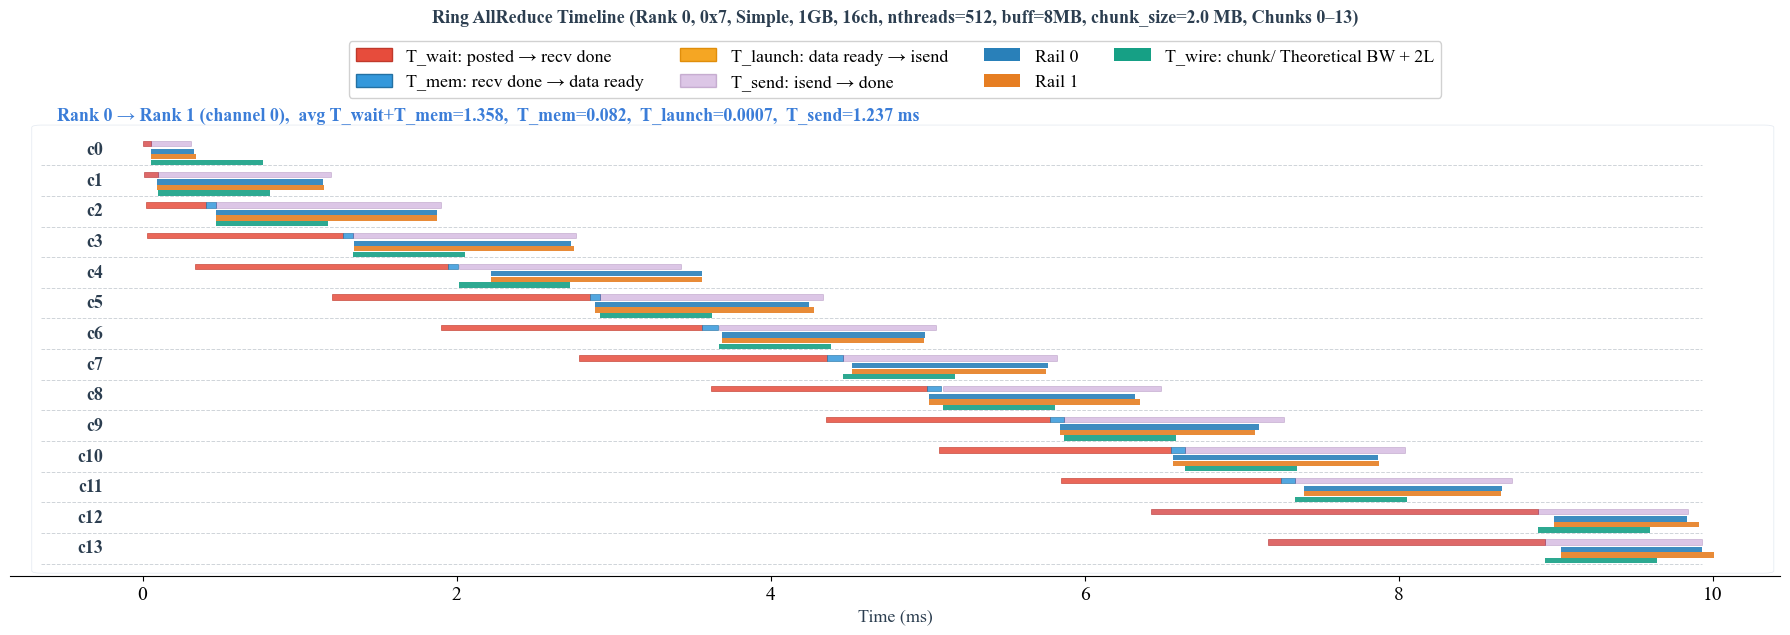

Saved: ring_timeline_0x7_Simple_16ch_nt512_buf8MB_1GB_chunks_0_13.png


In [7]:
# Generate plots for each config and message size (grouped by nchannels, one plot per nthreads/buffsize)
# ----- FILTER OPTIONS -----
# Set to None to allow all, or a list to restrict (e.g. FILTER_NCH = [1, 2]).
FILTER_NCH      = [16]       # e.g. [1, 2, 4, 8]
FILTER_PROTO    = ['Simple']          # e.g. ['Simple', 'LL', 'LL128']
FILTER_NTHREADS = [512]         # e.g. [256, 512]
FILTER_BUFFSIZE = ['8MB']         # e.g. ['2MB', '512KB']  (match info['buffsize'] exactly)
FILTER_MASK     = ['0x7']    # NCCL_TESTS_SPLIT_MASK suffixes to plot; None = all loaded

def _passes_filter(info):
    if FILTER_NCH is not None and info['nchannels'] not in FILTER_NCH:
        return False
    if FILTER_PROTO is not None and info['protocol'] not in FILTER_PROTO:
        return False
    if FILTER_NTHREADS is not None and info.get('nthreads') not in FILTER_NTHREADS:
        return False
    if FILTER_BUFFSIZE is not None and info.get('buffsize') not in FILTER_BUFFSIZE:
        return False
    return True

for cfg, cases in ring_data.items():
    if FILTER_MASK is not None and cfg not in FILTER_MASK:
        continue
    for info in cases:
        if not _passes_filter(info):
            continue
        msg_tag = info['msg_label'].replace(' ', '')
        nch_tag = info['nchannels']
        proto = info['protocol']
        nthreads_tag = info.get('nthreads', '')
        buffsize_tag = info.get('buffsize', '').replace(' ', '') if info.get('buffsize') else ''
        nchunks = info['nchunks_per_channel'] or 0

        fname_base = f'ring_timeline_{cfg}_{proto}_{nch_tag}ch_nt{nthreads_tag}_buf{buffsize_tag}_{msg_tag}'

        # Chunks 12-23 (only if enough chunks)
        if nchunks > 1:
            end = min(nchunks, 14)
            plot_ring_chunk_range(cfg, info, 0, end, f'Chunks 0\u2013{end-1}',
                f'{fname_base}_chunks_0_{end-1}.png')
        elif nchunks > 0:
            end = min(nchunks, 12)
            plot_ring_chunk_range(cfg, info, 0, end, f'Chunks 0\u2013{end-1}',
                f'{fname_base}_chunks_0_{end-1}.png')


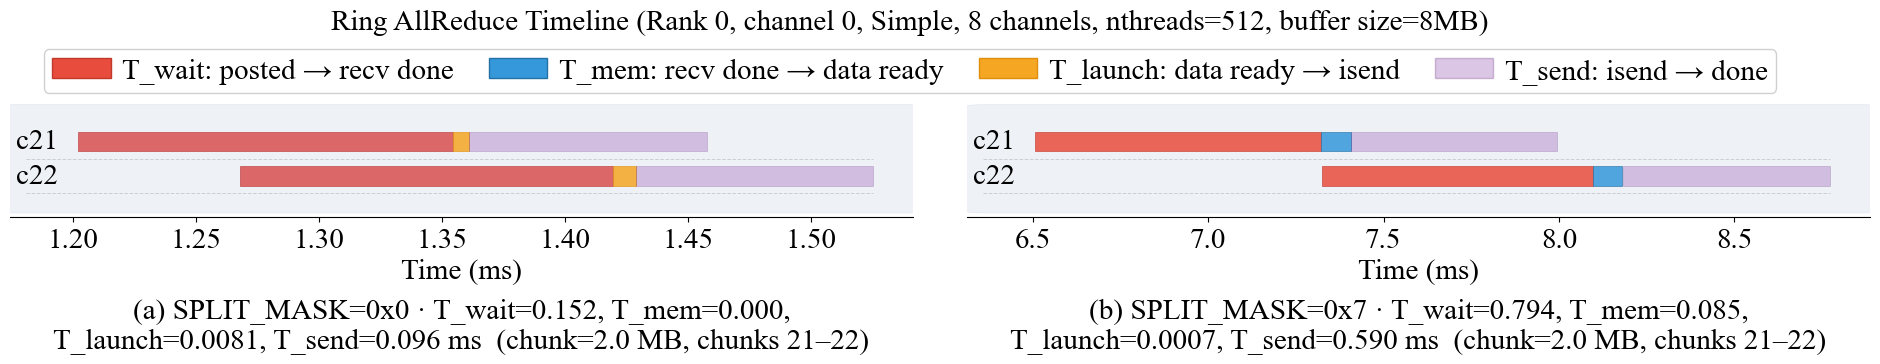

Saved: ring_timeline_PAIR_Simple_8ch_nt512_buf8MB.png


In [8]:
### Difference between 0x0 and 0x7 in Ring algorithm
# Paired timeline: LEFT = 0x0, RIGHT = 0x7 (same proto/nch/nthreads/buffsize/msg), conference-paper
# two-panel layout: shared top legend, (a)/(b) subplot tags, per-panel independent x-axis (Time ms),
# chunk labels only on the left panel, one shared "Time (ms)" label. All fonts = 16pt (== title).
import matplotlib.gridspec as _gridspec

FS = 21   # unified font size for EVERYTHING (title, subtitles, legend, ticks, chunk labels, header)

# All text: Times New Roman, black. (falls back to any available serif if Times New Roman missing)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['text.color']  = 'black'   # default text (annotations)
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'   # tick labels
plt.rcParams['ytick.color'] = 'black'

C_BG = '#FAFBFC'; C_POST_TO_RECVDONE='#E74C3C'; C_RECVDONE_TO_DR='#3498DB'
C_POST_TO_DR='#D94F4F'; C_DR_TO_TX='#F5A623'; C_TX_TO_DONE='#8E44AD'; C_TEXT='black'; C_RING='#3B7DD8'

def _draw_timeline_panel(ax, info, chunk_start, chunk_end, show_chunk_labels=True):
    """Draw one Rank-0 channel-0 timeline into ax. Returns (chunk_size_str, header_text)."""
    n_chunks = chunk_end - chunk_start
    box_height = 0.35; chunk_row_gap = 0.5; group_gap = 1.0; lane_h = 0.28
    r0_data = info['per_rank'][0]
    groups = []
    for s in sorted(r0_data['sends'], key=lambda s: s['channel']):
        if s['channel'] != 0:
            continue
        sliced = [c for c in s['chunks'] if chunk_start <= c['chunk_id'] < chunk_end]
        if sliced:
            groups.append((f"Rank 0 → Rank {s['peer']} (channel {s['channel']})", s['channel'], sliced))
    if not groups:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes, fontsize=FS)
        return None, None
    # Y layout
    y_map=[]; current_y=0
    for g in range(len(groups)):
        gy=[]
        for ci in range(n_chunks): gy.append(current_y); current_y-=chunk_row_gap
        y_map.append(gy); current_y-=group_gap
    y_top=y_map[0][0]+0.7; y_bottom=y_map[-1][-1]-0.6
    min_time=float('inf'); max_time=0
    for _,_,chunks in groups:
        for c in chunks:
            min_time=min(min_time,c['post_gap']); max_time=max(max_time,c['post_gap']+c['total'])
    time_span=max_time-min_time if max_time>min_time else 1.0
    chunk_id_x=min_time-time_span*0.025
    # chunk size string
    mb=info['msg_bytes']; nch=info['nchannels']; ncpc=info['nchunks_per_channel']; nr=info['nranks']
    cs=mb*2*(nr-1)/(nr*nch*ncpc) if ncpc else 0
    css=f"{cs/1024/1024:.1f} MB" if cs>=1024*1024 else (f"{cs/1024:.1f} KB" if cs>=1024 else f"{cs:.0f} B")
    # averages for header
    ch0=groups[0][2]
    a_dtx=np.mean([c['dr_to_tx'] for c in ch0])
    a_rdr=np.mean([c['recvdone_to_dr'] for c in ch0 if c.get('recvdone_to_dr') is not None]) if any(c.get('recvdone_to_dr') is not None for c in ch0) else 0
    a_txd=np.mean([c['tx_to_done'] for c in ch0])
    # T_wait = pure network wait (post_to_recvdone, the red bar); fall back to post_to_dr − T_mem
    if any(c.get('post_to_recvdone') is not None for c in ch0):
        a_ptr=np.mean([c['post_to_recvdone'] for c in ch0 if c.get('post_to_recvdone') is not None])
    else:
        a_ptr=np.mean([c['post_to_dr'] for c in ch0]) - a_rdr
    ax.set_facecolor('none')
    for g_idx,(label,ch,chunks) in enumerate(groups):
        g_yt=y_map[g_idx][0]; g_yb=y_map[g_idx][-1]
        ax.add_patch(mpatches.FancyBboxPatch(
            (chunk_id_x-time_span*0.04, g_yb-box_height/2-0.3),
            (max_time-chunk_id_x)+time_span*0.08, (g_yt-g_yb)+box_height+0.6,
            boxstyle="round,pad=0.06", facecolor='#EEF2F7', edgecolor='#E2E8F0', linewidth=0.5, zorder=0))
        for ci,c in enumerate(chunks):
            y=y_map[g_idx][ci]
            sep_y=y-chunk_row_gap/2
            ax.plot([chunk_id_x-time_span*0.04,max_time],[sep_y,sep_y],ls='--',color='#B0B8C0',lw=0.7,alpha=0.6,zorder=1)
            if show_chunk_labels:
                ax.text(chunk_id_x, y, f"c{c['chunk_id']}", ha='right', va='center',
                        fontsize=FS, color=C_TEXT, zorder=6)
            ptr=c.get('post_to_recvdone'); rdr=c.get('recvdone_to_dr'); x0=c['post_gap']
            if ptr is not None and rdr is not None:
                if ptr>0.001: ax.add_patch(FancyBboxPatch((x0,y-lane_h/2),ptr,lane_h,boxstyle="square,pad=0",facecolor=C_POST_TO_RECVDONE,edgecolor='#C0392B',linewidth=0.5,alpha=0.85,zorder=5))
                if rdr>0.001: ax.add_patch(FancyBboxPatch((x0+ptr,y-lane_h/2),rdr,lane_h,boxstyle="square,pad=0",facecolor=C_RECVDONE_TO_DR,edgecolor='#2471A3',linewidth=0.5,alpha=0.85,zorder=5))
            else:
                w=c['post_to_dr']
                if w>0.001: ax.add_patch(FancyBboxPatch((x0,y-lane_h/2),w,lane_h,boxstyle="square,pad=0",facecolor=C_POST_TO_DR,edgecolor='#B83A3A',linewidth=0.5,alpha=0.85,zorder=5))
            xd=c['post_gap']+c['post_to_dr']
            if c['dr_to_tx']>0.001: ax.add_patch(FancyBboxPatch((xd,y-lane_h/2),c['dr_to_tx'],lane_h,boxstyle="square,pad=0",facecolor=C_DR_TO_TX,edgecolor='#E08E0B',linewidth=0.5,alpha=0.85,zorder=5))
            xt=c['post_gap']+c['post_to_dr']+c['dr_to_tx']
            if c['tx_to_done']>0.001: ax.add_patch(FancyBboxPatch((xt,y-lane_h/2),c['tx_to_done'],lane_h,boxstyle="square,pad=0",facecolor=C_TX_TO_DONE,edgecolor='#6C3483',linewidth=0.5,alpha=0.3,zorder=5))
    ax.set_xlim(chunk_id_x-time_span*0.06, max_time+time_span*0.05)
    ax.set_ylim(y_bottom, y_top)
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_yticks([]); ax.tick_params(axis='x', labelsize=FS)
    # return the four avg values; the driver formats the 2-line caption (measured to fit @16pt)
    return css, (a_ptr, a_rdr, a_dtx, a_txd)

# ----- FILTER OPTIONS -----
FILTER_NCH      = [8]
FILTER_PROTO    = ['Simple']
FILTER_NTHREADS = [512]
FILTER_BUFFSIZE = ['8MB']

def _match(cases):
    for info in cases:
        if FILTER_NCH is not None and info['nchannels'] not in FILTER_NCH: continue
        if FILTER_PROTO is not None and info['protocol'] not in FILTER_PROTO: continue
        if FILTER_NTHREADS is not None and info.get('nthreads') not in FILTER_NTHREADS: continue
        if FILTER_BUFFSIZE is not None and info.get('buffsize') not in FILTER_BUFFSIZE: continue
        yield info

# pair 0x0 (left) and 0x7 (right) by (proto, nch, nthreads, buffsize).
# NOTE: the two masks may be swept at DIFFERENT message sizes (e.g. 0x0=8GB, 0x7=1GB),
# so msg_label is NOT part of the pairing key — each panel shows its own msg / chunk size.
def _key(info): return (info['protocol'], info['nchannels'], info.get('nthreads'), info.get('buffsize'))
left_by_key  = {_key(i): i for i in _match(ring_data.get('0x0', []))}
right_by_key = {_key(i): i for i in _match(ring_data.get('0x7', []))}
common = [k for k in left_by_key if k in right_by_key]

def _chunk_range(info):
    nchunks = info['nchunks_per_channel'] or 0
    if nchunks > 1:  return 21, min(nchunks, 23)
    elif nchunks > 0: return 0, min(nchunks, 12)
    return None, None

for k in common:
    li, ri = left_by_key[k], right_by_key[k]
    proto, nch, nth, buf = k
    csL_, ceL_ = _chunk_range(li); csR_, ceR_ = _chunk_range(ri)
    if csL_ is None or csR_ is None: continue

    # Height scales with the number of chunk rows so 2 rows aren't stretched like 4.
    n_rows = max(ceL_ - csL_, ceR_ - csR_)          # chunk rows shown per panel
    ROW_IN = 0.62                                    # inches per chunk row (the timeline itself)
    TOP_IN = 2.1                                     # inches reserved above plots (title + legend)
    BOT_IN = 2.2                                     # inches reserved below plots ((a)/(b) captions)
    plot_in = n_rows * ROW_IN
    fig_h = plot_in + TOP_IN + BOT_IN
    fig = plt.figure(figsize=(24, fig_h), facecolor='none')
    gs = _gridspec.GridSpec(1, 2, figure=fig, wspace=0.06)
    axL = fig.add_subplot(gs[0,0]); axR = fig.add_subplot(gs[0,1])
    cssL, avgL = _draw_timeline_panel(axL, li, csL_, ceL_, show_chunk_labels=True)
    cssR, avgR = _draw_timeline_panel(axR, ri, csR_, ceR_, show_chunk_labels=True)
    # per-panel "Time (ms)" axis label (independent x-axes)
    axL.set_xlabel('Time (ms)', fontsize=FS, color=C_TEXT)
    axR.set_xlabel('Time (ms)', fontsize=FS, color=C_TEXT)
    # (a)/(b) subfigure captions BELOW each panel (paper style). Exactly 2 lines, full metric
    # names: line1 = tag + first two avgs, line2 = last two avgs + chunk info (measured to fit @16pt).
    def _cap(tag, css, cs0, ce1, avg):
        pdr, rdr, dtx, txd = avg
        return (f"{tag} · T_wait={pdr:.3f}, T_mem={rdr:.3f},\n"
                f"T_launch={dtx:.4f}, T_send={txd:.3f} ms  (chunk={css}, chunks {cs0}–{ce1})")
    capL = _cap("(a) SPLIT_MASK=0x0", cssL, csL_, ceL_-1, avgL)
    capR = _cap("(b) SPLIT_MASK=0x7", cssR, csR_, ceR_-1, avgR)
    # place captions a fixed distance (in axes-height fractions) below the xlabel so they never
    # overlap it regardless of how short the plot area is.
    cap_dy = -(0.1 + 1.1 * ROW_IN / plot_in)   # deeper when the plot is short (few rows)
    axL.text(0.5, cap_dy, capL, transform=axL.transAxes, ha='center', va='top', fontsize=FS, color=C_TEXT)
    axR.text(0.5, cap_dy, capR, transform=axR.transAxes, ha='center', va='top', fontsize=FS, color=C_TEXT)
    # shared top legend (one row, centered)
    legend_elements = [
        mpatches.Patch(facecolor=C_POST_TO_RECVDONE, edgecolor='#C0392B', label='T_wait: posted → recv done'),
        mpatches.Patch(facecolor=C_RECVDONE_TO_DR, edgecolor='#2471A3', label='T_mem: recv done → data ready'),
        mpatches.Patch(facecolor=C_DR_TO_TX, edgecolor='#E08E0B', label='T_launch: data ready → isend'),
        mpatches.Patch(facecolor=C_TX_TO_DONE, edgecolor='#6C3483', alpha=0.3, label='T_send: isend → done'),
    ]
    # margins in figure fractions, from the fixed top/bottom inch reservations
    top_frac = 1.0 - TOP_IN / fig_h
    bot_frac = BOT_IN / fig_h
    fig.subplots_adjust(top=top_frac, bottom=bot_frac)
    # legend sits just above the plots; title just above the legend (in the reserved top band)
    fig.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, top_frac + 0.28 * (TOP_IN / fig_h)),
               ncol=4, fontsize=FS, framealpha=0.9, borderpad=0.3, handletextpad=0.4, columnspacing=1.2)
    nth_s = f", nthreads={nth}" if nth else ""; buf_s = f", buffer size={buf}" if buf else ""
    fig.suptitle(f'Ring AllReduce Timeline (Rank 0, channel 0, {proto}, {nch} channels{nth_s}{buf_s})',
                 fontsize=FS, color=C_TEXT, y=top_frac + 0.4 * (TOP_IN / fig_h))
    save_name = f'ring_timeline_PAIR_{proto}_{nch}ch_nt{nth}_buf{(buf or "").replace(" ","")}.png'
    plt.savefig(os.path.join(OUT_DIR, save_name), dpi=150, bbox_inches='tight', pad_inches=0.1, facecolor='none', transparent=True)
    plt.show()
    print(f"Saved: {save_name}")
